# Semantic embeddings

This notebook builds semantic representations of the movies. First, each movie is transformed into a natural language document by combining its textual metadata. These documents are then encoded into vector embeddings that will be used for semantic search and recommendation.

## Imports

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import umap.umap_ as umap

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Current working directory:", os.getcwd())

Current working directory: c:\Users\Darío\Desktop\OTROS\vector-recommender


## Load processed dataset

In [2]:
# Load the processed dataset
movies_df = pd.read_csv(
    "data/processed/tmdb_5000_movie_dataset/tmdb_5000_processed.csv"
)

# Display the first rows
movies_df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,tagline,title,vote_average,vote_count,cast,crew,release_year,release_month,profit,weighted_rating
0,237000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",2009.0,12.0,2.550965e+09,7.198875
1,300000000.0,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",2007.0,5.0,6.610000e+08,6.897852
2,245000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",2015.0,10.0,6.356746e+08,6.299443
3,250000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",2012.0,7.0,8.349391e+08,7.598016
4,260000000.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",2012.0,3.0,2.413910e+07,6.099956


In [3]:
# Display all column names
print(movies_df.columns.tolist())

['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew', 'release_year', 'release_month', 'profit', 'weighted_rating']


## Build Semantic Movie Documents

To enable semantic search, each movie is transformed into a natural language document that combines its most descriptive textual features.

The generated document includes the movie title, genres, overview, keywords and tagline (when available). Missing values are handled gracefully to ensure that each document remains coherent and suitable for embedding generation.

In [4]:
import ast

def clean_text(value):
    """
    Return a cleaned string or None if the value is missing.
    """
    if pd.isna(value):
        return None

    value = str(value).strip()

    if value == "":
        return None

    return value


def extract_names(value):
    """
    Extract the 'name' field from a TMDB JSON-like list.

    Returns an empty list if the value is missing, empty or invalid.
    """
    if pd.isna(value):
        return []

    value = str(value).strip()

    if value == "" or value == "[]":
        return []

    try:
        items = ast.literal_eval(value)
        return [item["name"] for item in items if "name" in item]
    except (ValueError, SyntaxError, TypeError):
        return []


def format_list(items):
    """
    Convert a list into a natural language string.

    Examples:
    ["Drama"] -> "Drama"
    ["Action", "Adventure"] -> "Action and Adventure"
    ["Action", "Adventure", "Fantasy"] ->
        "Action, Adventure and Fantasy"
    """
    if not items:
        return None

    if len(items) == 1:
        return items[0]

    if len(items) == 2:
        return f"{items[0]} and {items[1]}"

    return f"{', '.join(items[:-1])} and {items[-1]}"


def build_semantic_document(row):
    """
    Build a semantic document describing a movie.
    """

    title = clean_text(row["title"])
    overview = clean_text(row["overview"])
    tagline = clean_text(row["tagline"])

    genres = extract_names(row["genres"])
    keywords = extract_names(row["keywords"])

    parts = []

    # Movie title and genres
    if title:
        if genres:
            parts.append(
                f"{title} is a {format_list(genres)} movie."
            )
        else:
            parts.append(title)

    # Overview
    if overview:
        parts.append(
            f"Overview:\n{overview}"
        )

    # Keywords
    if keywords:
        parts.append(
            f"The movie explores themes such as {format_list(keywords)}."
        )

    # Tagline
    if tagline:
        parts.append(
            f'Tagline:\n"{tagline}"'
        )

    return "\n\n".join(parts)

## Inspect Semantic Documents

Before generating semantic documents for the entire dataset, the document generation function is tested on a small sample of movies to verify that the resulting text is coherent and that missing values are handled correctly.

In [5]:
# Preview semantic documents for a few movies
sample_indices = [0, 1, 2, 3, 4]

for idx in sample_indices:
    print(f"{'=' * 80}")
    print(f"Movie: {movies_df.loc[idx, 'title']}")
    print(f"{'=' * 80}")
    print(build_semantic_document(movies_df.loc[idx]))
    print("\n")

Movie: Avatar
Avatar is a Action, Adventure, Fantasy and Science Fiction movie.

Overview:
In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.

The movie explores themes such as culture clash, future, space war, space colony, society, space travel, futuristic, romance, space, alien, tribe, alien planet, cgi, marine, soldier, battle, love affair, anti war, power relations, mind and soul and 3d.

Tagline:
"Enter the World of Pandora."


Movie: Pirates of the Caribbean: At World's End
Pirates of the Caribbean: At World's End is a Adventure, Fantasy and Action movie.

Overview:
Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.

The movie explores themes such as ocean, drug abuse, exotic island, east india trading company, love of one's life, t

## Save semantic_document

In [10]:
# Generate semantic documents for all movies
movies_df["semantic_document"] = movies_df.apply(
    build_semantic_document,
    axis=1
)

# Save dataset with semantic documents
movies_df.to_csv(
    "data/processed/tmdb_5000_movie_dataset/tmdb_5000_semantic.csv",
    index=False
)

movies_df[
    ["title", "semantic_document"]
].head()

,title,semantic_document
0,Avatar,"Avatar is a Action, Adventure, Fantasy and Sci..."
1,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End is a ...
2,Spectre,"Spectre is a Action, Adventure and Crime movie..."
3,The Dark Knight Rises,"The Dark Knight Rises is a Action, Crime, Dram..."
4,John Carter,"John Carter is a Action, Adventure and Science..."


## Generate Semantic Embeddings

The semantic documents created in the previous step are converted into dense vector representations using a pre-trained Sentence Transformer model.

These embeddings capture the semantic meaning of each movie description, allowing similar movies to be retrieved through vector similarity rather than exact keyword matching. The resulting vectors will serve as the foundation of the recommendation engine.

### Load the Embedding Model

A pre-trained embedding model is loaded to encode each semantic document into a dense vector representation.

The **BAAI/bge-small-en-v1.5** model is specifically designed for semantic retrieval tasks, making it well suited for movie recommendation based on textual similarity.

In [13]:
# Load the embedding model
model = SentenceTransformer("BAAI/bge-small-en-v1.5")

c:\Users\Darío\Desktop\OTROS\vector-recommender\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Darío\.cache\huggingface\hub\models--BAAI--bge-small-en-v1.5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10326.58it/s]


### Encode Semantic Documents

Each semantic document is encoded into a fixed-length embedding vector. The vectors are L2-normalized so that cosine similarity can be efficiently computed during semantic search.

In [14]:
# Generate embeddings for all semantic documents
embeddings = model.encode(
    movies_df["semantic_document"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

print(embeddings.shape)

Batches: 100%|██████████| 151/151 [00:37<00:00,  4.08it/s]

(4803, 384)


In [34]:
# Save embeddings
np.save(
    "data/processed/tmdb_5000_movie_dataset/movie_embeddings.npy",
    embeddings
)

## Visualize the Embedding Space

Since the embedding vectors have 384 dimensions, they cannot be visualized directly.

To gain intuition about their semantic structure, the embeddings are projected into a two-dimensional space using UMAP. Movies with similar semantic content are expected to appear close together in this visualization.

In [17]:
# Reduce embeddings from 384 to 2 dimensions
reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

c:\Users\Darío\Desktop\OTROS\vector-recommender\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


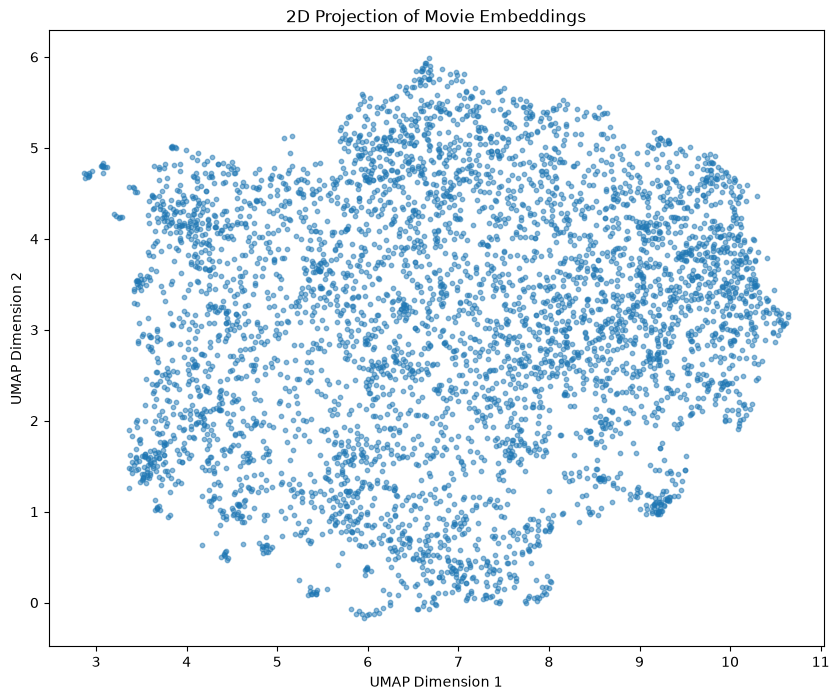

In [18]:
plt.figure(figsize=(10, 8))

plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=10,
    alpha=0.5
)

plt.title("2D Projection of Movie Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.show()

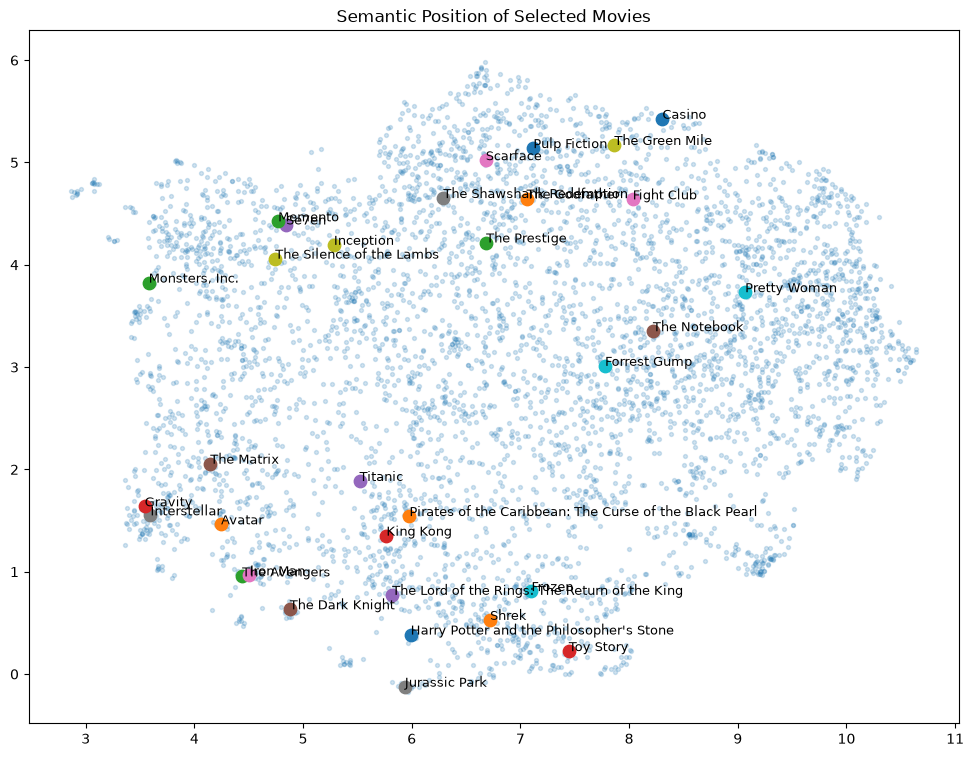

In [32]:
movies = [
    # Science Fiction
    "Avatar",
    "Interstellar",
    "Gravity",
    "Arrival",
    "Inception",
    "The Matrix",

    # Superheroes
    "The Dark Knight",
    "Iron Man",
    "The Avengers",

    # Animation
    "Toy Story",
    "Monsters, Inc.",
    "Frozen",
    "Shrek",

    # Crime
    "The Godfather",
    "Goodfellas",
    "Casino",
    "Scarface",
    "Pulp Fiction",

    # Drama
    "Titanic",
    "Forrest Gump",
    "The Shawshank Redemption",
    "The Green Mile",
    "Fight Club",

    # Fantasy
    "The Lord of the Rings: The Return of the King",
    "Harry Potter and the Philosopher's Stone",

    # Adventure
    "Pirates of the Caribbean: The Curse of the Black Pearl",
    "Jurassic Park",
    "King Kong",

    # Romance
    "La La Land",
    "The Notebook",
    "Pretty Woman",

    # Thriller
    "Se7en",
    "The Silence of the Lambs",
    "The Prestige",
    "Memento"
]

selected = movies_df[movies_df["title"].isin(movies)]

plt.figure(figsize=(12, 9))

plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=8,
    alpha=0.2
)

for idx in selected.index:
    plt.scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        s=80
    )

    plt.text(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        movies_df.loc[idx, "title"],
        fontsize=9
    )

plt.title("Semantic Position of Selected Movies")
plt.show()

## Semantic Movie Retrieval

A user query is encoded using the same embedding model as the movie documents.

The query embedding is then compared against all movie embeddings using cosine similarity. The movies with the highest similarity scores are returned as semantic recommendations.

In [35]:
def recommend_movies(query, movies_df, embeddings, model, top_k=10):
    """
    Recommend movies based on semantic similarity.
    """

    # Encode the user query
    query_embedding = model.encode(
        [query],
        normalize_embeddings=True
    )

    # Compute cosine similarity
    similarities = cosine_similarity(
        query_embedding,
        embeddings
    )[0]

    # Get indices of the most similar movies
    top_indices = np.argsort(similarities)[::-1][:top_k]

    # Build results
    results = movies_df.iloc[top_indices][
        [
            "title",
            "release_year",
            "genres",
            "vote_average",
            "weighted_rating"
        ]
    ].copy()

    results["similarity"] = similarities[top_indices]

    return results

In [36]:
query = "An emotional science fiction movie about space exploration"

recommend_movies(
    query,
    movies_df,
    embeddings,
    model
)

,title,release_year,genres,vote_average,weighted_rating,similarity
239,Gravity,2013.0,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...",7.3,7.297485,0.750000
4332,Silent Running,1972.0,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 18, ""...",6.3,6.286805,0.743778
2966,2001: A Space Odyssey,1968.0,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...",7.9,7.892793,0.737041
158,Star Trek,2009.0,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...",7.4,7.396536,0.733039
549,Sphere,1998.0,"[{""id"": 878, ""name"": ""Science Fiction""}]",5.8,5.807185,0.731411
220,Prometheus,2012.0,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...",6.3,6.299510,0.723476
2755,Earth to Echo,2014.0,"[{""id"": 10751, ""name"": ""Family""}, {""id"": 12, ""...",5.7,5.715583,0.715323
373,Mission to Mars,2000.0,"[{""id"": 878, ""name"": ""Science Fiction""}]",5.7,5.712352,0.713430
2129,The Black Hole,1979.0,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 10751...",6.1,6.099343,0.713427
3624,Moon,2009.0,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...",7.6,7.589981,0.712890


In [37]:
query = "A funny animated movie about friendship"

recommend_movies(
    query,
    movies_df,
    embeddings,
    model
)

,title,release_year,genres,vote_average,weighted_rating,similarity
3718,Fugly,2014.0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",5.3,NaN,0.710215
837,Free Birds,2013.0,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 35, ""...",5.7,5.717692,0.703163
3038,Hey Arnold! The Movie,2002.0,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...",5.6,5.679812,0.702108
3900,Air Bud,1997.0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10751, ""...",5.3,5.380560,0.696165
2699,Fun Size,2012.0,"[{""id"": 35, ""name"": ""Comedy""}]",5.5,5.548672,0.692537
578,Alvin and the Chipmunks: The Squeakquel,2009.0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10751, ""...",5.4,5.412251,0.686773
1620,Winnie the Pooh,2011.0,"[{""id"": 16, ""name"": ""Animation""}, {""id"": 10751...",6.8,6.768541,0.686526
4022,Robot & Frank,2012.0,"[{""id"": 878, ""name"": ""Science Fiction""}, {""id""...",6.8,6.781615,0.680656
2171,My Best Friend's Girl,2008.0,"[{""id"": 10749, ""name"": ""Romance""}, {""id"": 35, ...",5.4,5.435802,0.679119
3247,That Awkward Moment,2014.0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",6.1,6.099908,0.677569


In [38]:
query = "A dark crime story about the mafia"

recommend_movies(
    query,
    movies_df,
    embeddings,
    model
)

,title,release_year,genres,vote_average,weighted_rating,similarity
1558,Analyze This,1999.0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 80, ""nam...",6.4,6.392827,0.700077
3337,The Godfather,1972.0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",8.4,8.395310,0.685437
1847,GoodFellas,1990.0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",8.2,8.191945,0.681949
2775,Find Me Guilty,2006.0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 28, ""name...",6.5,6.467374,0.660683
2731,The Godfather: Part II,1974.0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",8.3,8.292091,0.659522
613,The Score,2001.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",6.7,6.683232,0.650062
3409,Criminal Activities,2015.0,"[{""id"": 53, ""name"": ""Thriller""}, {""id"": 80, ""n...",5.8,5.828738,0.646754
2801,The Funeral,1996.0,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 18, ""name...",7.3,6.962932,0.646371
1728,We Own the Night,2007.0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",6.5,6.485391,0.645360
877,Black Mass,2015.0,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 18, ""name...",6.3,6.298011,0.645053
